# Notebook 03: Safety Directions

Finds directions in activation space that separate benign from sensitive biological content.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.metrics import confusion_matrix
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from activations import ActivationDataset
from safety import SafetyDirectionFinder, correlate_with_concepts
from probes import BiologicalProbe
import visualization as viz
plt.style.use('seaborn-v0_8-darkgrid')
print('=' * 70)
print('BIOLENS: SAFETY DIRECTION IDENTIFICATION')
print('=' * 70)

BIOLENS: SAFETY DIRECTION IDENTIFICATION


## 1. Load Activation Dataset

In [2]:
print('\n[1/4] Loading activation dataset...')
dataset_path = Path.cwd().parent / 'data' / 'processed' / 'activation_dataset_v1'
dataset = ActivationDataset.load(str(dataset_path))
print(f'✓ Loaded: {dataset.n_prompts} prompts, {len(dataset.layers)} layers')
if 'safety_level' not in dataset.labels:
    print('\n⚠️  Safety labels not found. Creating synthetic safety labels for demo...')
    safety_labels = np.zeros(dataset.n_prompts, dtype=int)
    texts = np.array(dataset.texts)
    sensitive_keywords = ['synthesis', 'production', 'CRISPR', 'gain-of-function']
    for i, text in enumerate(texts):
        for keyword in sensitive_keywords:
            if keyword.lower() in text.lower():
                safety_labels[i] = 1
                break
    dataset.labels['safety_level'] = safety_labels
    n_sensitive = int(np.sum(safety_labels))
    print(f'✓ Created synthetic labels: {n_sensitive} sensitive, {len(safety_labels)-n_sensitive} benign')


[1/4] Loading activation dataset...
✓ Loaded: 10 prompts, 24 layers

⚠️  Safety labels not found. Creating synthetic safety labels for demo...
✓ Created synthetic labels: 1 sensitive, 9 benign


## 2. Find Safety Directions

In [3]:
print('\n[2/4] Finding safety directions across layers...')
finder = SafetyDirectionFinder(n_folds=5, method='logistic')
result = finder.analyze(
    activations_by_layer=dataset.activations,
    labels=dataset.labels['safety_level'],
    benign_label=0,
    sensitive_label=1,
)
print(f'\n✓ Found safety directions for all {len(result.directions)} layers')
print(f'✓ Best layer: {result.best_layer} (AUROC: {result.best_auroc:.3f})')


[2/4] Finding safety directions across layers...
Finding safety directions across layers...
  layer_0: AUROC=nan, separation=34.96
  layer_1: AUROC=nan, separation=35.20
  layer_2: AUROC=nan, separation=34.22
  layer_3: AUROC=nan, separation=33.67
  layer_4: AUROC=nan, separation=29.81
  layer_5: AUROC=nan, separation=28.87
  layer_6: AUROC=nan, separation=28.82
  layer_7: AUROC=nan, separation=29.76
  layer_8: AUROC=nan, separation=29.21
  layer_9: AUROC=nan, separation=31.14
  layer_10: AUROC=nan, separation=30.21
  layer_11: AUROC=nan, separation=28.02
  layer_12: AUROC=nan, separation=26.94
  layer_13: AUROC=nan, separation=26.88
  layer_14: AUROC=nan, separation=26.66
  layer_15: AUROC=nan, separation=23.89
  layer_16: AUROC=nan, separation=25.52
  layer_17: AUROC=nan, separation=24.03
  layer_18: AUROC=nan, separation=23.10
  layer_19: AUROC=nan, separation=23.02
  layer_20: AUROC=nan, separation=23.60
  layer_21: AUROC=nan, separation=22.10
  layer_22: AUROC=nan, separation=22.

/Users/spoddar/Downloads/Career/Pivot/bio-interp/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/Users/spoddar/Downloads/Career/Pivot/bio-interp/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/spoddar/Downloads/Career/Pivot/bio-interp/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 2.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Trac

## 3. Analyze Best Direction

In [4]:
print('\n[3/4] Analyzing best safety direction...')
best_direction = result.get_best_direction()
print(f'\nBest Safety Direction ({result.best_layer}):')
print(f'  AUROC: {best_direction.auroc:.3f}')
print(f'  AUPRC: {best_direction.auprc:.3f}')
print(f"  Cohen's d (separation): {best_direction.separation:.2f}")
print(f'  Decision threshold: {best_direction.threshold:.3f}')
print(f'  Benign mean projection: {best_direction.mean_benign_proj:.3f}')
print(f'  Sensitive mean projection: {best_direction.mean_sensitive_proj:.3f}')
activations_best_layer = dataset.activations[result.best_layer]
projections = activations_best_layer @ best_direction.direction
benign_proj = projections[dataset.labels['safety_level'] == 0]
sensitive_proj = projections[dataset.labels['safety_level'] == 1]


[3/4] Analyzing best safety direction...

Best Safety Direction (layer_0):
  AUROC: nan
  AUPRC: 1.000
  Cohen's d (separation): 34.96
  Decision threshold: 4.732
  Benign mean projection: -0.869
  Sensitive mean projection: 10.334


## 4. Visualizations


[4/4] Generating visualizations...


✓ Saved figure: 03_safety_projections.png
✓ Saved figure: 03_safety_auroc_by_layer.png


✓ Saved figure: 03_safety_classification.png


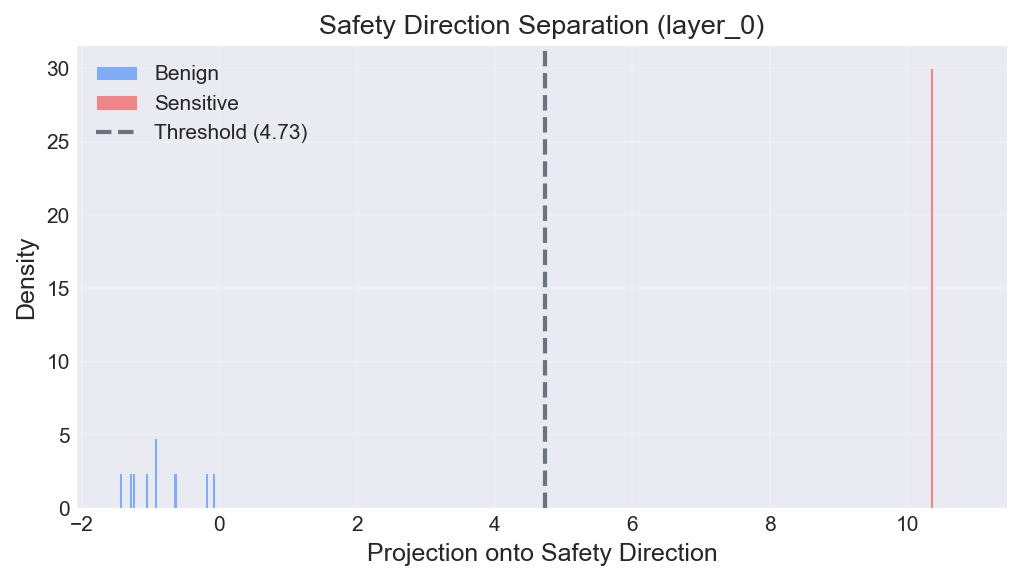

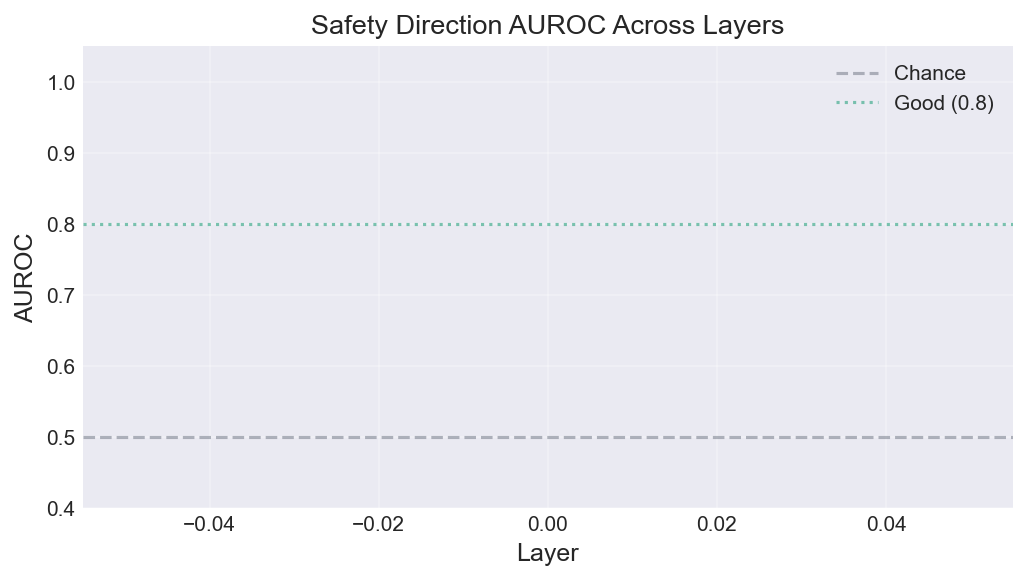

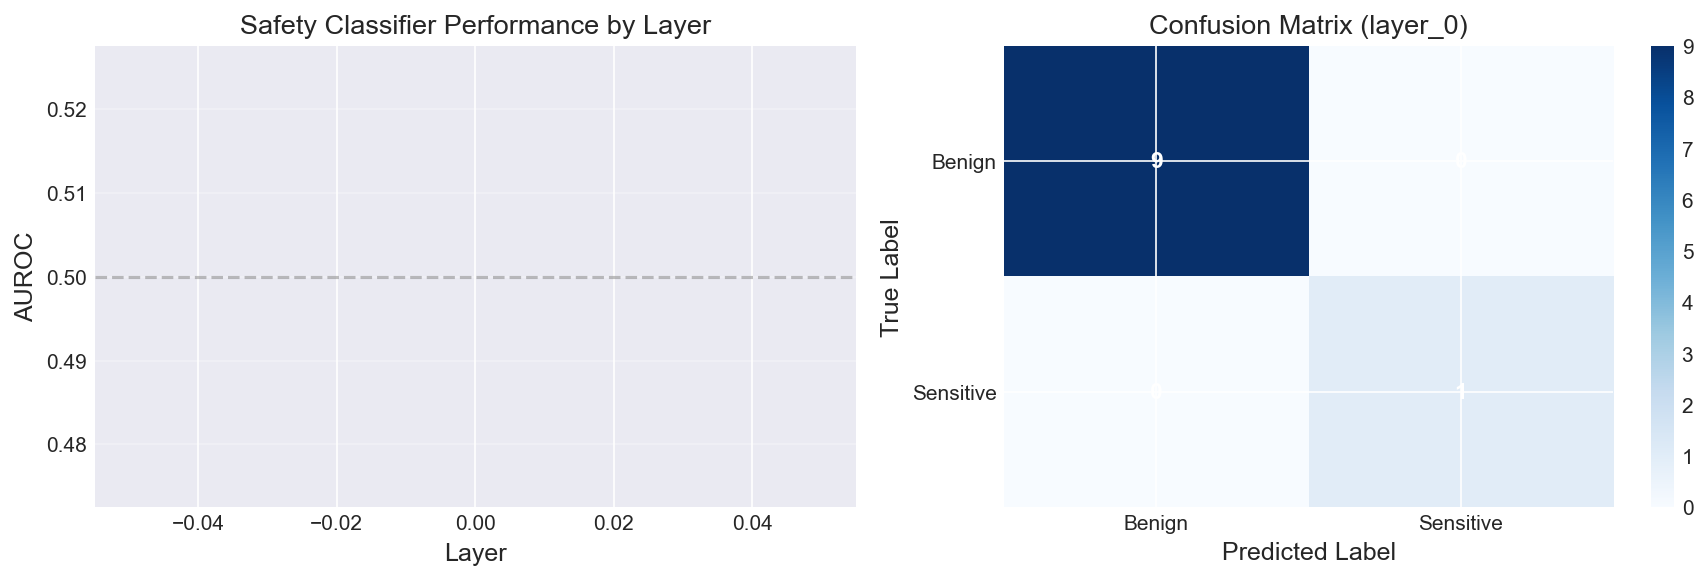

In [5]:
print('\n[4/4] Generating visualizations...')
figures_dir = Path.cwd().parent / 'results' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
fig = viz.plot_safety_projections(benign_proj, sensitive_proj, best_direction.threshold, save_path=str(figures_dir / '03_safety_projections.png'), title=f'Safety Direction Separation ({result.best_layer})')
print('✓ Saved figure: 03_safety_projections.png')
fig = viz.plot_layer_auroc_curve(result.layer_aurocs, save_path=str(figures_dir / '03_safety_auroc_by_layer.png'), title='Safety Direction AUROC Across Layers')
print('✓ Saved figure: 03_safety_auroc_by_layer.png')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
layers = sorted(result.layer_aurocs.keys(), key=lambda x: int(x.split('_')[1]))
aurocs = [result.layer_aurocs[l] for l in layers]
layer_nums = [int(l.split('_')[1]) for l in layers]
axes[0].bar(layer_nums, aurocs, color='#2563EB', alpha=0.7, edgecolor='white')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Layer'); axes[0].set_ylabel('AUROC')
axes[0].set_title('Safety Classifier Performance by Layer')
axes[0].grid(True, alpha=0.3, axis='y')
predictions = (projections > best_direction.threshold).astype(int)
actual = dataset.labels['safety_level']
cm = confusion_matrix(actual, predictions)
im = axes[1].imshow(cm, cmap='Blues', aspect='auto')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Benign','Sensitive']); axes[1].set_yticklabels(['Benign','Sensitive'])
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
axes[1].set_title(f'Confusion Matrix ({result.best_layer})')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i,j]), ha='center', va='center', color='white', fontweight='bold')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig(figures_dir / '03_safety_classification.png', dpi=300, bbox_inches='tight')
print('✓ Saved figure: 03_safety_classification.png')
plt.show()

## 5. Save Results

In [6]:
print('\nSaving safety direction results...')
output_dir = Path.cwd().parent / 'results' / 'safety_analysis'
output_dir.mkdir(parents=True, exist_ok=True)
safety_summary = {
    'best_layer': result.best_layer,
    'best_auroc': float(result.best_auroc),
    'layer_aurocs': {k: float(v) for k, v in result.layer_aurocs.items()},
    'best_direction_stats': {
        'auroc': float(best_direction.auroc),
        'auprc': float(best_direction.auprc),
        'separation': float(best_direction.separation),
        'threshold': float(best_direction.threshold),
        'mean_benign_proj': float(best_direction.mean_benign_proj),
        'mean_sensitive_proj': float(best_direction.mean_sensitive_proj),
    },
}
with open(output_dir / 'safety_summary.json', 'w') as f:
    json.dump(safety_summary, f, indent=2)
print(f'✓ Saved to {output_dir / "safety_summary.json"}')
print('\n' + '=' * 70)
print('✓ Notebook 03 complete!')
print('=' * 70)


Saving safety direction results...
✓ Saved to /Users/spoddar/Downloads/Career/Pivot/bio-interp/results/safety_analysis/safety_summary.json

✓ Notebook 03 complete!
